# Machine Learning with PyTorch and Scikit-Learn  
# -- Code Examples

In [ ]:
!pip install numpy matplotlib scikit-learn

## Obtaining and preparing the MNIST dataset

The MNIST dataset is publicly available at http://yann.lecun.com/exdb/mnist/ and consists of the following four parts:

- Training set images: train-images-idx3-ubyte.gz (9.9 MB, 47 MB unzipped, 60,000 examples)
- Training set labels: train-labels-idx1-ubyte.gz (29 KB, 60 KB unzipped, 60,000 labels)
- Test set images: t10k-images-idx3-ubyte.gz (1.6 MB, 7.8 MB, 10,000 examples)
- Test set labels: t10k-labels-idx1-ubyte.gz (5 KB, 10 KB unzipped, 10,000 labels)



In [ ]:
from sklearn.datasets import fetch_openml


X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


In [ ]:
X = ((X / 255.) - .5) * 2

Visualize the first digit of each class:

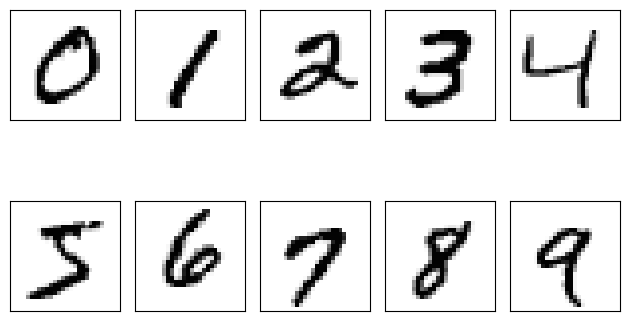

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
    img = X[y == i][0].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_4.png', dpi=300)
plt.show()

Visualize 25 different versions of "7":

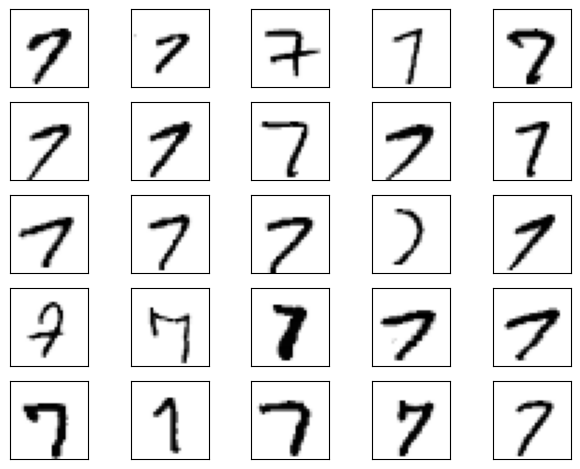

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(25):
    img = X[y == 7][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
# plt.savefig('figures/11_5.png', dpi=300)
plt.show()

Split into training, validation, and test set:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=123,
    stratify=y
)
del X, y

In [ ]:
import numpy as np

num_epochs = 50
minibatch_size = 100


def minibatch_generator(X, y, minibatch_size):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start_idx in range(0, indices.shape[0] - minibatch_size
                           + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]

        yield X[batch_idx], y[batch_idx]


# iterate over training epochs
for i in range(num_epochs):

    # iterate over minibatches
    minibatch_gen = minibatch_generator(
        X_train, y_train, minibatch_size)

    for X_train_mini, y_train_mini in minibatch_gen:

        break

    break

print(X_train_mini.shape)
print(y_train_mini.shape)

(100, 784)
(100,)


Defining a function to compute the loss and accuracy

In [ ]:
def mse_loss(targets, probas, num_labels=10):
    onehot_targets = int_to_onehot(targets, num_labels=num_labels)
    return np.mean((onehot_targets - probas)**2)


def accuracy(targets, predicted_labels):
    return np.mean(predicted_labels == targets)

# Implementing **a single hidden layer**

In [ ]:
import numpy as np

In [ ]:
##########################
### MODEL
##########################

def sigmoid(z):
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


class NeuralNetMLP:

    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        super().__init__()

        self.num_classes = num_classes

        # hidden
        rng = np.random.RandomState(random_seed)

        self.weight_h = rng.normal(
            loc=0.0, scale=0.1, size=(num_hidden, num_features))
        self.bias_h = np.zeros(num_hidden)

        # output
        self.weight_out = rng.normal(
            loc=0.0, scale=0.1, size=(num_classes, num_hidden))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # Hidden layer
        # input dim: [n_examples, n_features] dot [n_hidden, n_features].T
        # output dim: [n_examples, n_hidden]
        z_h = np.dot(x, self.weight_h.T) + self.bias_h
        a_h = sigmoid(z_h)

        # Output layer
        # input dim: [n_examples, n_hidden] dot [n_classes, n_hidden].T
        # output dim: [n_examples, n_classes]
        z_out = np.dot(a_h, self.weight_out.T) + self.bias_out
        a_out = sigmoid(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):

        #########################
        ### Output layer weights
        #########################

        # onehot encoding
        y_onehot = int_to_onehot(y, self.num_classes)

        # Part 1: dLoss/dOutWeights
        ## = dLoss/dOutAct * dOutAct/dOutNet * dOutNet/dOutWeight
        ## where DeltaOut = dLoss/dOutAct * dOutAct/dOutNet
        ## for convenient re-use

        # input/output dim: [n_examples, n_classes]
        d_loss__d_a_out = 2.*(a_out - y_onehot) / y.shape[0]

        # input/output dim: [n_examples, n_classes]
        d_a_out__d_z_out = a_out * (1. - a_out) # sigmoid derivative

        # output dim: [n_examples, n_classes]
        delta_out = d_loss__d_a_out * d_a_out__d_z_out # "delta (rule) placeholder"

        # gradient for output weights

        # [n_examples, n_hidden]
        d_z_out__dw_out = a_h

        # input dim: [n_classes, n_examples] dot [n_examples, n_hidden]
        # output dim: [n_classes, n_hidden]
        d_loss__dw_out = np.dot(delta_out.T, d_z_out__dw_out)
        d_loss__db_out = np.sum(delta_out, axis=0)


        #################################
        # Part 2: dLoss/dHiddenWeights
        ## = DeltaOut * dOutNet/dHiddenAct * dHiddenAct/dHiddenNet * dHiddenNet/dWeight

        # [n_classes, n_hidden]
        d_z_out__a_h = self.weight_out

        # output dim: [n_examples, n_hidden]
        d_loss__a_h = np.dot(delta_out, d_z_out__a_h)

        # [n_examples, n_hidden]
        d_a_h__d_z_h = a_h * (1. - a_h) # sigmoid derivative

        # [n_examples, n_features]
        d_z_h__d_w_h = x

        # output dim: [n_hidden, n_features]
        d_loss__d_w_h = np.dot((d_loss__a_h * d_a_h__d_z_h).T, d_z_h__d_w_h)
        d_loss__d_b_h = np.sum((d_loss__a_h * d_a_h__d_z_h), axis=0)

        return (d_loss__dw_out, d_loss__db_out,
                d_loss__d_w_h, d_loss__d_b_h)

In [ ]:
model_single_hidden_layer = NeuralNetMLP(num_features=28*28,
                     num_hidden=50,
                     num_classes=10)

In [ ]:
_, probas = model_single_hidden_layer.forward(X_test)
mse = mse_loss(y_test, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_test, predicted_labels)

print(f'Initial validation MSE: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation MSE: 0.3
Initial validation accuracy: 9.2%


In [ ]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)

    for i, (features, targets) in enumerate(minibatch_gen):

        # Use *_, to unpack intermediate hidden layer outputs and get the final probabilities
        *_, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)

        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()

        num_examples += targets.shape[0]
        mse += loss

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    return mse, acc

In [ ]:
mse, acc = compute_mse_and_acc(model_single_hidden_layer, X_test, y_test)
print(f'Initial valid MSE: {mse:.1f}')
print(f'Initial valid accuracy: {acc*100:.1f}%')

Initial valid MSE: 0.3
Initial valid accuracy: 9.2%


In [ ]:
def train_single_hidden_layer(model, X_train, y_train, X_valid, y_valid, num_epochs,
          learning_rate=0.1):

    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []

    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:

            #### Compute outputs ####
            a_h, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__dw_out, d_loss__db_out, \
            d_loss__dw_h, d_loss__db_h = \
                model.backward(X_train_mini, a_h, a_out, y_train_mini)

            #### Update weights ####
            model.weight_h -= learning_rate * d_loss__dw_h
            model.bias_h -= learning_rate * d_loss__db_h
            model.weight_out -= learning_rate * d_loss__dw_out
            model.bias_out -= learning_rate * d_loss__db_out

        #### Epoch Logging ####
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [ ]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_valid_acc = train_single_hidden_layer(
    model_single_hidden_layer, X_train, y_train, X_test, y_test,
    num_epochs=50, learning_rate=0.1)

Epoch: 001/050 | Train MSE: 0.05 | Train Acc: 74.70% | Valid Acc: 74.41%
Epoch: 002/050 | Train MSE: 0.03 | Train Acc: 84.20% | Valid Acc: 84.24%
Epoch: 003/050 | Train MSE: 0.03 | Train Acc: 87.56% | Valid Acc: 87.49%
Epoch: 004/050 | Train MSE: 0.02 | Train Acc: 88.69% | Valid Acc: 88.68%
Epoch: 005/050 | Train MSE: 0.02 | Train Acc: 89.84% | Valid Acc: 89.67%
Epoch: 006/050 | Train MSE: 0.02 | Train Acc: 90.40% | Valid Acc: 90.25%
Epoch: 007/050 | Train MSE: 0.02 | Train Acc: 90.84% | Valid Acc: 90.65%
Epoch: 008/050 | Train MSE: 0.02 | Train Acc: 91.17% | Valid Acc: 91.03%
Epoch: 009/050 | Train MSE: 0.02 | Train Acc: 91.42% | Valid Acc: 91.29%
Epoch: 010/050 | Train MSE: 0.01 | Train Acc: 91.65% | Valid Acc: 91.45%
Epoch: 011/050 | Train MSE: 0.01 | Train Acc: 91.97% | Valid Acc: 91.84%
Epoch: 012/050 | Train MSE: 0.01 | Train Acc: 92.18% | Valid Acc: 91.85%
Epoch: 013/050 | Train MSE: 0.01 | Train Acc: 92.38% | Valid Acc: 92.05%
Epoch: 014/050 | Train MSE: 0.01 | Train Acc: 92.60

## Evaluating the neural network performance

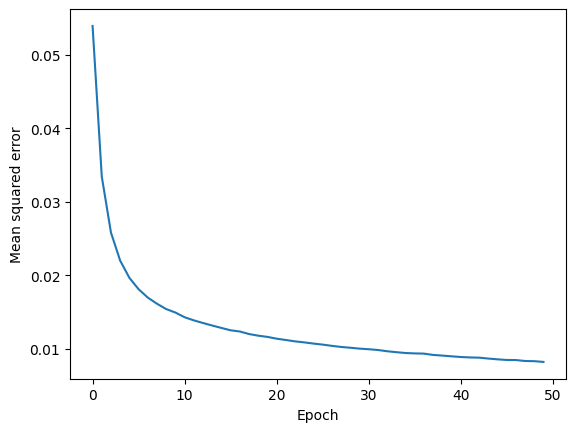

In [ ]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
#plt.savefig('figures/11_07.png', dpi=300)
plt.show()

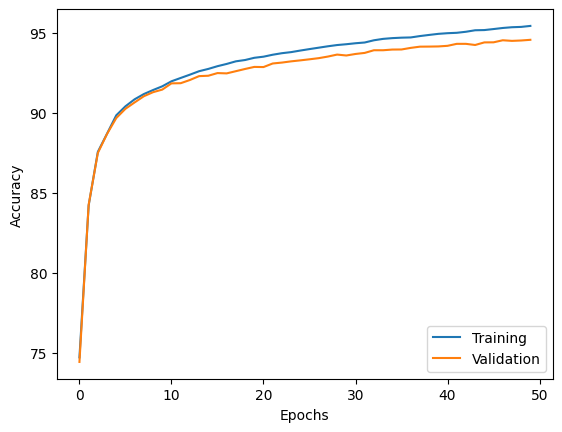

In [ ]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
#plt.savefig('figures/11_08.png', dpi=300)
plt.show()

In [ ]:
test_mse, test_acc = compute_mse_and_acc(model_single_hidden_layer, X_test, y_test)
print(f'Test accuracy: {test_acc*100:.2f}%')

Test accuracy: 94.56%


Plot failure cases:

In [ ]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

_, probas = model_single_hidden_layer.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)

misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

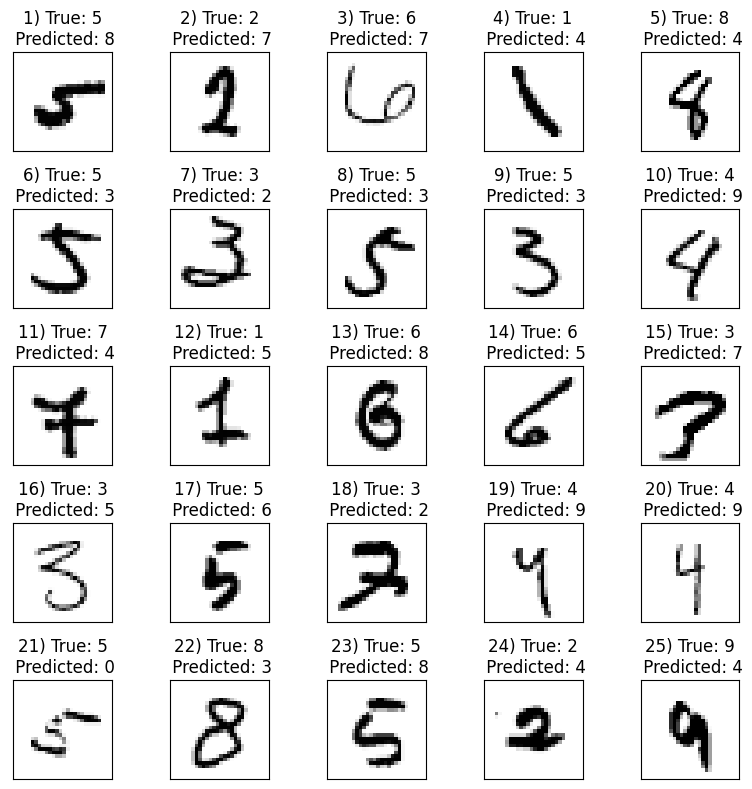

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5,
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_09.png', dpi=300)
plt.show()

# Implementing **two hidden layer**

In [ ]:
def sigmoid(z):
    return 1. / (1. + np.exp(-z))


def int_to_onehot(y, num_labels):

    ary = np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary

def softmax(z):
    # Subtract max for numerical stability (prevents overflow)
    e_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e_z / np.sum(e_z, axis=1, keepdims=True)

class NeuralNetMLP2HL:

    def __init__(self, num_features, num_hidden1, num_hidden2, num_classes, random_seed=123):
        super().__init__()

        self.num_classes = num_classes
        rng = np.random.RandomState(random_seed)

        # first hidden layer
        self.weight_h1 = rng.normal(loc=0.0, scale=0.1, size=(num_hidden1, num_features))
        self.bias_h1 = np.zeros(num_hidden1)

        # second hidden layer
        self.weight_h2 = rng.normal(loc=0.0, scale=0.1, size=(num_hidden2, num_hidden1))
        self.bias_h2 = np.zeros(num_hidden2)

        # output layer
        self.weight_out = rng.normal(loc=0.0, scale=0.1, size=(num_classes, num_hidden2))
        self.bias_out = np.zeros(num_classes)

    def forward(self, x):
        # first hidden layer
        z_h1 = np.dot(x, self.weight_h1.T) + self.bias_h1
        a_h1 = sigmoid(z_h1)

        # second hidden layer
        z_h2 = np.dot(a_h1, self.weight_h2.T) + self.bias_h2
        a_h2 = sigmoid(z_h2)

        # output layer
        z_out = np.dot(a_h2, self.weight_out.T) + self.bias_out
        a_out = softmax(z_out)

        return a_h1, a_h2, a_out

    def backward(self, x, a_h1, a_h2, a_out, y):
        y_onehot = int_to_onehot(y, self.num_classes)
        n_samples = y.shape[0]

        # -----------------------
        # Output layer gradients
        # -----------------------
        # MSE loss derivative: ∂L/∂a_out
        d_loss__d_a_out = 2. * (a_out - y_onehot) / n_samples

        # Vectorized softmax Jacobian computation
        # For softmax: ∂s_i/∂z_j = s_i * (δ_ij - s_j)
        # This gives us: delta = d_loss/d_a @ Jacobian
        # Expanding: delta_j = Σ_i [d_loss/d_a_i * s_i * (δ_ij - s_j)]
        #                    = d_loss/d_a_j * s_j - s_j * Σ_i [d_loss/d_a_i * s_i]

        delta_out = d_loss__d_a_out * a_out - a_out * np.sum(d_loss__d_a_out * a_out, axis=1, keepdims=True)

        d_loss__dw_out = np.dot(delta_out.T, a_h2)
        d_loss__db_out = np.sum(delta_out, axis=0)

        # -----------------------
        # Second hidden layer gradients
        # -----------------------
        delta_h2 = np.dot(delta_out, self.weight_out) * (a_h2 * (1. - a_h2))
        d_loss__dw_h2 = np.dot(delta_h2.T, a_h1)
        d_loss__db_h2 = np.sum(delta_h2, axis=0)

        # -----------------------
        # First hidden layer gradients
        # -----------------------
        delta_h1 = np.dot(delta_h2, self.weight_h2) * (a_h1 * (1. - a_h1))
        d_loss__dw_h1 = np.dot(delta_h1.T, x)
        d_loss__db_h1 = np.sum(delta_h1, axis=0)

        return (d_loss__dw_h1, d_loss__db_h1,
                d_loss__dw_h2, d_loss__db_h2,
                d_loss__dw_out, d_loss__db_out)

    def update_weights(self, dW1, db1, dW2, db2, dW_out, db_out, lr=0.1):
        self.weight_h1 -= lr * dW1
        self.bias_h1 -= lr * db1
        self.weight_h2 -= lr * dW2
        self.bias_h2 -= lr * db2
        self.weight_out -= lr * dW_out
        self.bias_out -= lr * db_out

In [ ]:
model_two_hidden_layer = NeuralNetMLP2HL(num_features=28*28,
                     num_hidden1=500,
                     num_hidden2=500,
                     num_classes=10)

In [ ]:
_, _, probas = model_two_hidden_layer.forward(X_test)
mse = mse_loss(y_test, probas)

predicted_labels = np.argmax(probas, axis=1)
acc = accuracy(y_test, predicted_labels)

print(f'Initial validation MSE: {mse:.1f}')
print(f'Initial validation accuracy: {acc*100:.1f}%')

Initial validation MSE: 0.1
Initial validation accuracy: 9.9%


In [ ]:
def compute_mse_and_acc(nnet, X, y, num_labels=10, minibatch_size=100):
    mse, correct_pred, num_examples = 0., 0, 0
    minibatch_gen = minibatch_generator(X, y, minibatch_size)

    for i, (features, targets) in enumerate(minibatch_gen):

        # Use *_, to unpack intermediate hidden layer outputs and get the final probabilities
        *_, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)

        onehot_targets = int_to_onehot(targets, num_labels=num_labels)
        loss = np.mean((onehot_targets - probas)**2)
        correct_pred += (predicted_labels == targets).sum()

        num_examples += targets.shape[0]
        mse += loss

    mse = mse/(i+1)
    acc = correct_pred/num_examples
    return mse, acc

# Calculate Macro AUC
from sklearn.metrics import roc_auc_score

def compute_macro_auc(model, X, y, num_classes=10):
    # Get probabilities
    if hasattr(model, 'predict'): # Keras
        y_probs = model.predict(X)
    else: # Scratch
        # For 2-layer scratch
        if hasattr(model, 'weight_h2'):
            _, _, y_probs = model.forward(X)
        # For 1-layer scratch
        else:
            _, y_probs = model.forward(X)

    # Convert true labels to one-hot for AUC calculation
    y_true_onehot = int_to_onehot(y, num_classes)

    # Calculate Macro AUC
    macro_auc = roc_auc_score(y_true_onehot, y_probs, average='macro', multi_class='ovr')
    return macro_auc

In [ ]:
def train_two_hidden_layer(model, X_train, y_train, X_valid, y_valid, num_epochs, minibatch_size=100, learning_rate=0.1):

    epoch_loss = []
    epoch_train_acc = []
    epoch_valid_acc = []

    for e in range(num_epochs):

        # iterate over minibatches
        minibatch_gen = minibatch_generator(
            X_train, y_train, minibatch_size)

        for X_train_mini, y_train_mini in minibatch_gen:

            #### Compute outputs ####
            a_h1, a_h2, a_out = model.forward(X_train_mini)

            #### Compute gradients ####
            d_loss__dw_h1, d_loss__db_h1, \
            d_loss__dw_h2, d_loss__db_h2, \
            d_loss__dw_out, d_loss__db_out = \
                model.backward(X_train_mini, a_h1, a_h2, a_out, y_train_mini)

            #### Update weights ####
            model.update_weights(d_loss__dw_h1, d_loss__db_h1,
                                 d_loss__dw_h2, d_loss__db_h2,
                                 d_loss__dw_out, d_loss__db_out,
                                 lr=learning_rate)

        #### Epoch Logging ####
        train_mse, train_acc = compute_mse_and_acc(model, X_train, y_train)
        valid_mse, valid_acc = compute_mse_and_acc(model, X_valid, y_valid)
        train_acc, valid_acc = train_acc*100, valid_acc*100
        epoch_train_acc.append(train_acc)
        epoch_valid_acc.append(valid_acc)
        epoch_loss.append(train_mse)
        print(f'Epoch: {e+1:03d}/{num_epochs:03d} '
              f'| Train MSE: {train_mse:.2f} '
              f'| Train Acc: {train_acc:.2f}% '
              f'| Valid Acc: {valid_acc:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

In [ ]:
np.random.seed(123) # for the training set shuffling

epoch_loss, epoch_train_acc, epoch_valid_acc = train_two_hidden_layer(
    model_two_hidden_layer, X_train, y_train, X_test, y_test,
    num_epochs=20, minibatch_size=100, learning_rate=0.1)

Epoch: 001/020 | Train MSE: 0.02 | Train Acc: 86.42% | Valid Acc: 86.20%
Epoch: 002/020 | Train MSE: 0.02 | Train Acc: 89.31% | Valid Acc: 89.16%
Epoch: 003/020 | Train MSE: 0.01 | Train Acc: 90.78% | Valid Acc: 90.51%
Epoch: 004/020 | Train MSE: 0.01 | Train Acc: 91.63% | Valid Acc: 91.25%
Epoch: 005/020 | Train MSE: 0.01 | Train Acc: 92.15% | Valid Acc: 91.58%
Epoch: 006/020 | Train MSE: 0.01 | Train Acc: 92.56% | Valid Acc: 92.21%
Epoch: 007/020 | Train MSE: 0.01 | Train Acc: 93.06% | Valid Acc: 92.33%
Epoch: 008/020 | Train MSE: 0.01 | Train Acc: 93.22% | Valid Acc: 92.60%
Epoch: 009/020 | Train MSE: 0.01 | Train Acc: 93.70% | Valid Acc: 92.90%
Epoch: 010/020 | Train MSE: 0.01 | Train Acc: 93.59% | Valid Acc: 92.75%
Epoch: 011/020 | Train MSE: 0.01 | Train Acc: 94.34% | Valid Acc: 93.50%
Epoch: 012/020 | Train MSE: 0.01 | Train Acc: 94.26% | Valid Acc: 93.32%
Epoch: 013/020 | Train MSE: 0.01 | Train Acc: 94.64% | Valid Acc: 93.83%
Epoch: 014/020 | Train MSE: 0.01 | Train Acc: 94.89

In [ ]:
test_mse, test_acc = compute_mse_and_acc(model_two_hidden_layer, X_test, y_test)
auc_score = compute_macro_auc(model_two_hidden_layer, X_test, y_test)

print(f"2-Layer Model:")
print(f"Total loss on Testing Set: {test_mse:.2f}")
print(f'Accuracy of Testing Set: {test_acc*100:.2f}%')
print(f"Macro AUC: {auc_score:.4f}")


2-Layer Model:
Total loss on Testing Set: 0.01
Accuracy of Testing Set: 95.00%
Macro AUC: 0.9966


#### Plots

In [ ]:
plt.plot(range(len(epoch_loss)), epoch_loss)
plt.ylabel('Mean squared error')
plt.xlabel('Epoch')
plt.show()

In [ ]:
plt.plot(range(len(epoch_train_acc)), epoch_train_acc,
         label='Training')
plt.plot(range(len(epoch_valid_acc)), epoch_valid_acc,
         label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(loc='lower right')
plt.title('2-HL Accuracy') # Added title
#plt.savefig('figures/11_08.png', dpi=300)
plt.show()

In [ ]:
X_test_subset = X_test[:1000, :]
y_test_subset = y_test[:1000]

_, _, probas = model_two_hidden_layer.forward(X_test_subset)
test_pred = np.argmax(probas, axis=1)

misclassified_images = X_test_subset[y_test_subset != test_pred][:25]
misclassified_labels = test_pred[y_test_subset != test_pred][:25]
correct_labels = y_test_subset[y_test_subset != test_pred][:25]

In [ ]:
fig, ax = plt.subplots(nrows=5, ncols=5,
                       sharex=True, sharey=True, figsize=(8, 8))
ax = ax.flatten()
for i in range(25):
    img = misclassified_images[i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys', interpolation='nearest')
    ax[i].set_title(f'{i+1}) '
                    f'True: {correct_labels[i]}\n'
                    f' Predicted: {misclassified_labels[i]}')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
#plt.savefig('figures/11_09.png', dpi=300)
plt.show()

# Implementing **a Fully Connected ANN with Keras (TensorFlow)**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Ensure reproducibility
tf.random.set_seed(123)

# Define the initializer to match your manual code (Normal, scale=0.1)
init_strategy = keras.initializers.RandomNormal(mean=0.0, stddev=0.1)

model_keras = keras.Sequential([
    #keras.Input(shape=(28*28,)),
    # Apply the initializer to every layer

    layers.Dense(500, activation='sigmoid', kernel_initializer=init_strategy, name='hidden_1'),
    layers.Dense(500, activation='sigmoid', kernel_initializer=init_strategy, name='hidden_2'),
    layers.Dense(10, activation='softmax', kernel_initializer=init_strategy, name='output')
])

# Display the model summary
model_keras.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

In [ ]:
# Compile the Keras model
# We'll use the SGD optimizer and `MSE` as the loss function since our labels are integers.
model_keras.compile(
    loss="mse",
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    metrics=["accuracy"]
)

In [ ]:
# Train the Keras Model
# We'll train the model for 50 epochs, similar to the custom implementations.
history = model_keras.fit(
    X_train, y_train_onehot,
    epochs=50,
    batch_size=100, # Using the same minibatch size
)

print("Training finished.")

Epoch 1/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1794 - loss: 0.0899
Epoch 2/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4113 - loss: 0.0798
Epoch 3/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5355 - loss: 0.0679
Epoch 4/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6746 - loss: 0.0566
Epoch 5/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7530 - loss: 0.0472
Epoch 6/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8034 - loss: 0.0398
Epoch 7/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8348 - loss: 0.0342
Epoch 8/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8495 - loss: 0.0302
Epoch 9/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8600 - loss: 0.0273
Epoch 10/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8669 - loss: 0.0251
Epoch 11/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8719 - loss: 0.0235
Epoch 12/50
490/490 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model_keras.evaluate(X_test, y_test_onehot, verbose=0)
print(f'Keras Test Loss: {loss:.4f}')
print(f'Keras Test Accuracy: {accuracy*100:.2f}%')

Keras Test Loss: 0.0129
Keras Test Accuracy: 91.82%


# Compare the predictive performance

** We assume you finished running all the previous blocks

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# Evaluate 1-layer model:
m1_mse, m1_acc = compute_mse_and_acc(model_single_hidden_layer, X_test, y_test)
m1_auc = compute_macro_auc(model_single_hidden_layer, X_test, y_test)

# Evaluate 2-layer model:
m2_mse, m2_acc = compute_mse_and_acc(model_two_hidden_layer, X_test, y_test)
m2_auc = compute_macro_auc(model_two_hidden_layer, X_test, y_test)

# Evaluate Keras model:
y_test_onehot = to_categorical(y_test, num_classes=10)

k_loss, k_acc = model_keras.evaluate(X_test, y_test_onehot, verbose=0)
k_probs = model_keras.predict(X_test, verbose=0)
k_auc = roc_auc_score(y_test_onehot, k_probs, average='macro', multi_class='ovr')

# Create Comparison Table
results_df = pd.DataFrame({
    'Model': ['1-Layer (Baseline)', '2-Layer (Your Code)', '2-Layer (Keras)'],
    'Test Accuracy': [f"{m1_acc*100:.2f}%", f"{m2_acc*100:.2f}%", f"{k_acc*100:.2f}%"],
    'Macro AUC': [f"{m1_auc:.4f}", f"{m2_auc:.4f}", f"{k_auc:.4f}"],
    'Test MSE': [f"{m1_mse:.4f}", f"{m2_mse:.4f}", f"{k_loss:.4f}"]
})

print(results_df)

                 Model Test Accuracy Macro AUC Test MSE
0   1-Layer (Baseline)        94.56%    0.9926   0.0094
1  2-Layer (Your Code)        95.00%    0.9966   0.0079
2      2-Layer (Keras)        91.82%    0.9925   0.0129
